# DMB: profile, tSZ, and \(P(k)\) suppression (To et al. 2024 Table 1)

One-at-a-time scans of the **literature** DMB parameters (`convention="literature"`). Each row is one parameter; **three columns**:

1. Halo **electron-pressure profile** \(P_e(r)\) at \(M_{200c}=10^{14}\,h^{-1}M_\odot\), \(z=0.3\)
2. **tSZ** \(D_\ell^{yy}\)
3. **Matter suppression** \(P_{\rm hydro}(k)/P_{\rm DMO}(k)\) at the same \(z\)

Priors from To et al. (2024) Table 1. \(\sigma_{\ln Y}\) is \(Y\)–\(M\) scatter only — it does not change these three predictions, so it is omitted.

`hm_consistency=False` for **tSZ**. **`hm_consistency=True` for \(P(k)\) suppression** (hmfast adds a lowest-mass counterterm to **both** \(P_{1h}\) and \(P_{2h}\); To et al. eq. 5.3 is the 2h piece \(A=1-I(k{=}0)\)). All DMB profiles use **`convention="literature"`**. Matter \(P(k)\) truncates at \(16\,R_{200c}\) and scales \(\rho_\mathrm{dmb}\) to the same kernel \(M_\mathrm{tot}\) as DMO so \(S(k)\to 1\) at low \(k\) for every Table 1 parameter. Pressure / tSZ keep the unscaled hydro profile.

In [1]:
import os

# JAX XLA profiling 0.1
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"
# optional, also used elsewhere in hmfast:
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")


USE_GPU = True  # set False for CPU-only
if not USE_GPU:
    os.environ["JAX_PLATFORMS"] = "cpu"

# Enable XLA profiler hook (writes .profile output on exit/runs)

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.profiles import DMBPressureProfile, DMBMatterProfile, DMBNFWMatterProfile
from hmfast.halos.profiles.dmb import dmb_halo_quantities
from hmfast.tracers import tSZTracer, CMBLensingTracer

print("USE_GPU =", USE_GPU)
print("JAX devices:", jax.devices())
print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))

USE_GPU = True
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]
XLA_FLAGS: None


## Cosmology, halo model, grids

Modest grids keep interactive runtime reasonable; increase `nM` / `nz` / `nell` for production plots.

In [2]:
cosmo = Cosmology(emulator_set="lcdm:v1")
hm = HaloModel(cosmology=cosmo, hm_consistency=False)
hm_pk = hm.update(hm_consistency=True)
assert hm.hm_consistency is False and hm_pk.hm_consistency is True

cp = cosmo._cosmo_params()
h = float(cp["h"])
Ob0, Om0 = float(cp["Omega_b"]), float(cp["Omega0_m"])
m = jnp.logspace(12.5, 15.0, 24) / h   # physical Msun
z = jnp.linspace(0.05, 1.2, 16)
ell = jnp.logspace(np.log10(30.0), np.log10(3000.0), 40)
k_arr = jnp.logspace(-3.0, 1.0, 48)
z_sk = 0.3
m_prof = 1e14 / h
c_prof = 5.0

print(f"tSZ hm_consistency={hm.hm_consistency}, P(k) hm_consistency={hm_pk.hm_consistency}, h={h:.3f}")
print(f"grids: nM={m.size}, nz={z.size}, nell={ell.size}, nk={k_arr.size}")

tSZ hm_consistency=False, P(k) hm_consistency=True, h=0.680
grids: nM=24, nz=16, nell=40, nk=48


## Helpers

Literature DMB (`convention="literature"`). `cl_yy` → `hm`; `pk_mm` → `hm_pk` (`hm_consistency=True`).

In [3]:
NINT = 32
DETA_FID = 0.3

FID = {
    "log10_Mc0": 14.83,
    "nu_z": 0.0,
    "mu_beta": 0.21,
    "theta_ej_0": 4.0,
    "gamma_rhogas": 2.0,
    "delta_rhogas": 7.0,
    "alpha_nt": 0.18,
    "eta_star": 0.3,
    "deta": DETA_FID,
}

# To et al. 2024 Table 1 (gas + stellar). Values: prior edge / fiducial / prior edge.
SCANS = [
    (r"$\log_{10}M_{c0}$", "log10_Mc0", [13.0, 14.83, 15.0]),
    (r"$\nu_z$", "nu_z", [-1.0, 0.0, 1.0]),
    (r"$\mu$", "mu_beta", [0.1, 0.21, 1.5]),
    (r"$\theta_{\rm ej}$", "theta_ej_0", [2.0, 4.0, 6.0]),
    (r"$\gamma$", "gamma_rhogas", [1.0, 2.0, 4.0]),
    (r"$\delta$", "delta_rhogas", [3.0, 7.0, 11.0]),
    (r"$\alpha_{\rm nt}$", "alpha_nt", [0.01, 0.18, 0.4]),
    (r"$\eta$", "eta_star", [0.21, 0.3, 0.36]),
    (r"$\delta\eta$", "deta", [0.05, 0.3, 0.4]),
]


def dmb_kw(**overrides):
    """Map Table 1 keys onto DMB profile kwargs (literature convention only)."""
    p = dict(FID)
    p.update(overrides)
    deta = p.pop("deta")
    kw = dict(
        convention="literature",
        num_points_trapz_int=NINT,
        log10_Mc0=p["log10_Mc0"],
        nu_z=p["nu_z"],
        mu_beta=p["mu_beta"],
        theta_ej_0=p["theta_ej_0"],
        gamma_rhogas=p["gamma_rhogas"],
        delta_rhogas=p["delta_rhogas"],
        alpha_nt=p["alpha_nt"],
        eta_star=p["eta_star"],
        eta_cga=p["eta_star"] + deta,
    )
    assert kw["convention"] == "literature"
    return kw


def to_dell(cl, ell_arr=ell):
    ell_arr = np.asarray(ell_arr)
    return ell_arr * (ell_arr + 1.0) * np.asarray(cl) / (2.0 * np.pi)


def cl_yy(**overrides):
    tsz = tSZTracer(profile=DMBPressureProfile(**dmb_kw(**overrides)))
    c1 = hm.cl_1h(tsz, None, ell, m, z)
    c2 = hm.cl_2h(tsz, None, ell, m, z)
    return np.asarray(c1 + c2)


def pk_mm(**overrides):
    tr = CMBLensingTracer(profile=DMBMatterProfile(**dmb_kw(**overrides)))
    return np.asarray(
        hm_pk.pk_1h(tr, None, k_arr, m, z) + hm_pk.pk_2h(tr, None, k_arr, m, z)
    )


def pe_profile(**overrides):
    from hmfast.halos.profiles.dmb import _param_dict
    prof = DMBPressureProfile(**dmb_kw(**overrides))
    q = dmb_halo_quantities(m_prof, z_sk, c_prof, Ob0, Om0, h, _param_dict(prof))
    return np.asarray(q["r_over_r200"]), np.asarray(q["Pe"])

## Fiducial $D_\ell^{yy}$

finite: True   max D_ell: 5.358117990434638e-14


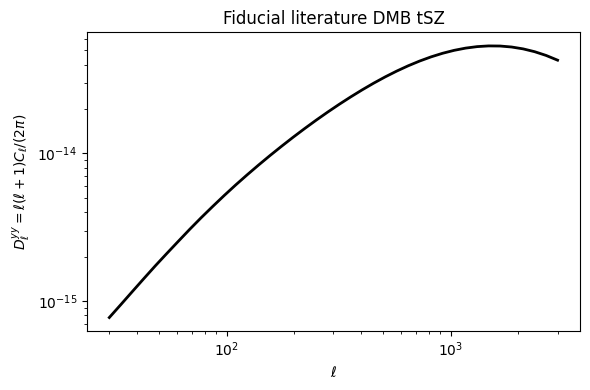

In [4]:
cl_fid = cl_yy()
dl_fid = to_dell(cl_fid)
print("finite:", np.all(np.isfinite(dl_fid)), "  max D_ell:", float(np.max(dl_fid)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ell, dl_fid, "k-", lw=2)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell^{yy}=\ell(\ell+1)C_\ell/(2\pi)$")
ax.set_title(r"Fiducial literature DMB tSZ")
plt.tight_layout()
plt.show()

## Side-by-side: profile / tSZ / \(P(k)\) suppression

Nine Table 1 parameters (rows). Columns: \(P_e(r/R_{200c})\), \(D_\ell^{yy}\), \(P_{\rm hydro}/P_{\rm DMO}\) with **`hm_pk` (`hm_consistency=True`)**. Thick black = fiducial.


In [5]:
scan_pe, scan_cl, scan_Sk = {}, {}, {}
for title, key, values in SCANS:
    scan_pe[key], scan_cl[key], scan_Sk[key] = {}, {}, {}
    for v in values:
        kw = {key: v}
        x, pe = pe_profile(**kw)
        cl = cl_yy(**kw)
        scan_pe[key][v] = (x, pe)
        scan_cl[key][v] = cl
        print(f"{key}={v}: max Pe={pe.max():.3e}, max D_ell={to_dell(cl).max():.3e}")

lens_dmo = CMBLensingTracer(profile=DMBNFWMatterProfile(**dmb_kw()))
pk_dmo = np.asarray(
    hm_pk.pk_1h(lens_dmo, None, k_arr, m, z) + hm_pk.pk_2h(lens_dmo, None, k_arr, m, z)
)
zi = int(np.argmin(np.abs(np.asarray(z) - z_sk)))
print(f"S(k) at z={float(z[zi]):.3f}")

for title, key, values in SCANS:
    for v in values:
        pk = pk_mm(**{key: v})
        S = pk[:, zi] / np.maximum(pk_dmo[:, zi], 1e-30)
        scan_Sk[key][v] = S
        print(f"{key}={v}: S(k_max)={float(S[-1]):.3f}")


log10_Mc0=13.0: max Pe=1.457e+01, max D_ell=2.702e-13
log10_Mc0=14.83: max Pe=2.321e+00, max D_ell=5.358e-14
log10_Mc0=15.0: max Pe=1.957e+00, max D_ell=4.625e-14
nu_z=-1.0: max Pe=2.606e+00, max D_ell=6.255e-14
nu_z=0.0: max Pe=2.321e+00, max D_ell=5.358e-14
nu_z=1.0: max Pe=2.070e+00, max D_ell=4.633e-14
mu_beta=0.1: max Pe=3.621e+00, max D_ell=6.392e-14
mu_beta=0.21: max Pe=2.321e+00, max D_ell=5.358e-14
mu_beta=1.5: max Pe=1.131e-01, max D_ell=2.668e-14
theta_ej_0=2.0: max Pe=6.632e+00, max D_ell=1.891e-13
theta_ej_0=4.0: max Pe=2.321e+00, max D_ell=5.358e-14
theta_ej_0=6.0: max Pe=1.328e+00, max D_ell=2.625e-14
gamma_rhogas=1.0: max Pe=1.242e+01, max D_ell=5.463e-13
gamma_rhogas=2.0: max Pe=2.321e+00, max D_ell=5.358e-14
gamma_rhogas=4.0: max Pe=6.221e-01, max D_ell=8.370e-15
delta_rhogas=3.0: max Pe=3.457e-01, max D_ell=3.345e-15
delta_rhogas=7.0: max Pe=2.321e+00, max D_ell=5.358e-14
delta_rhogas=11.0: max Pe=8.253e+00, max D_ell=3.253e-13
alpha_nt=0.01: max Pe=2.323e+00, max D_

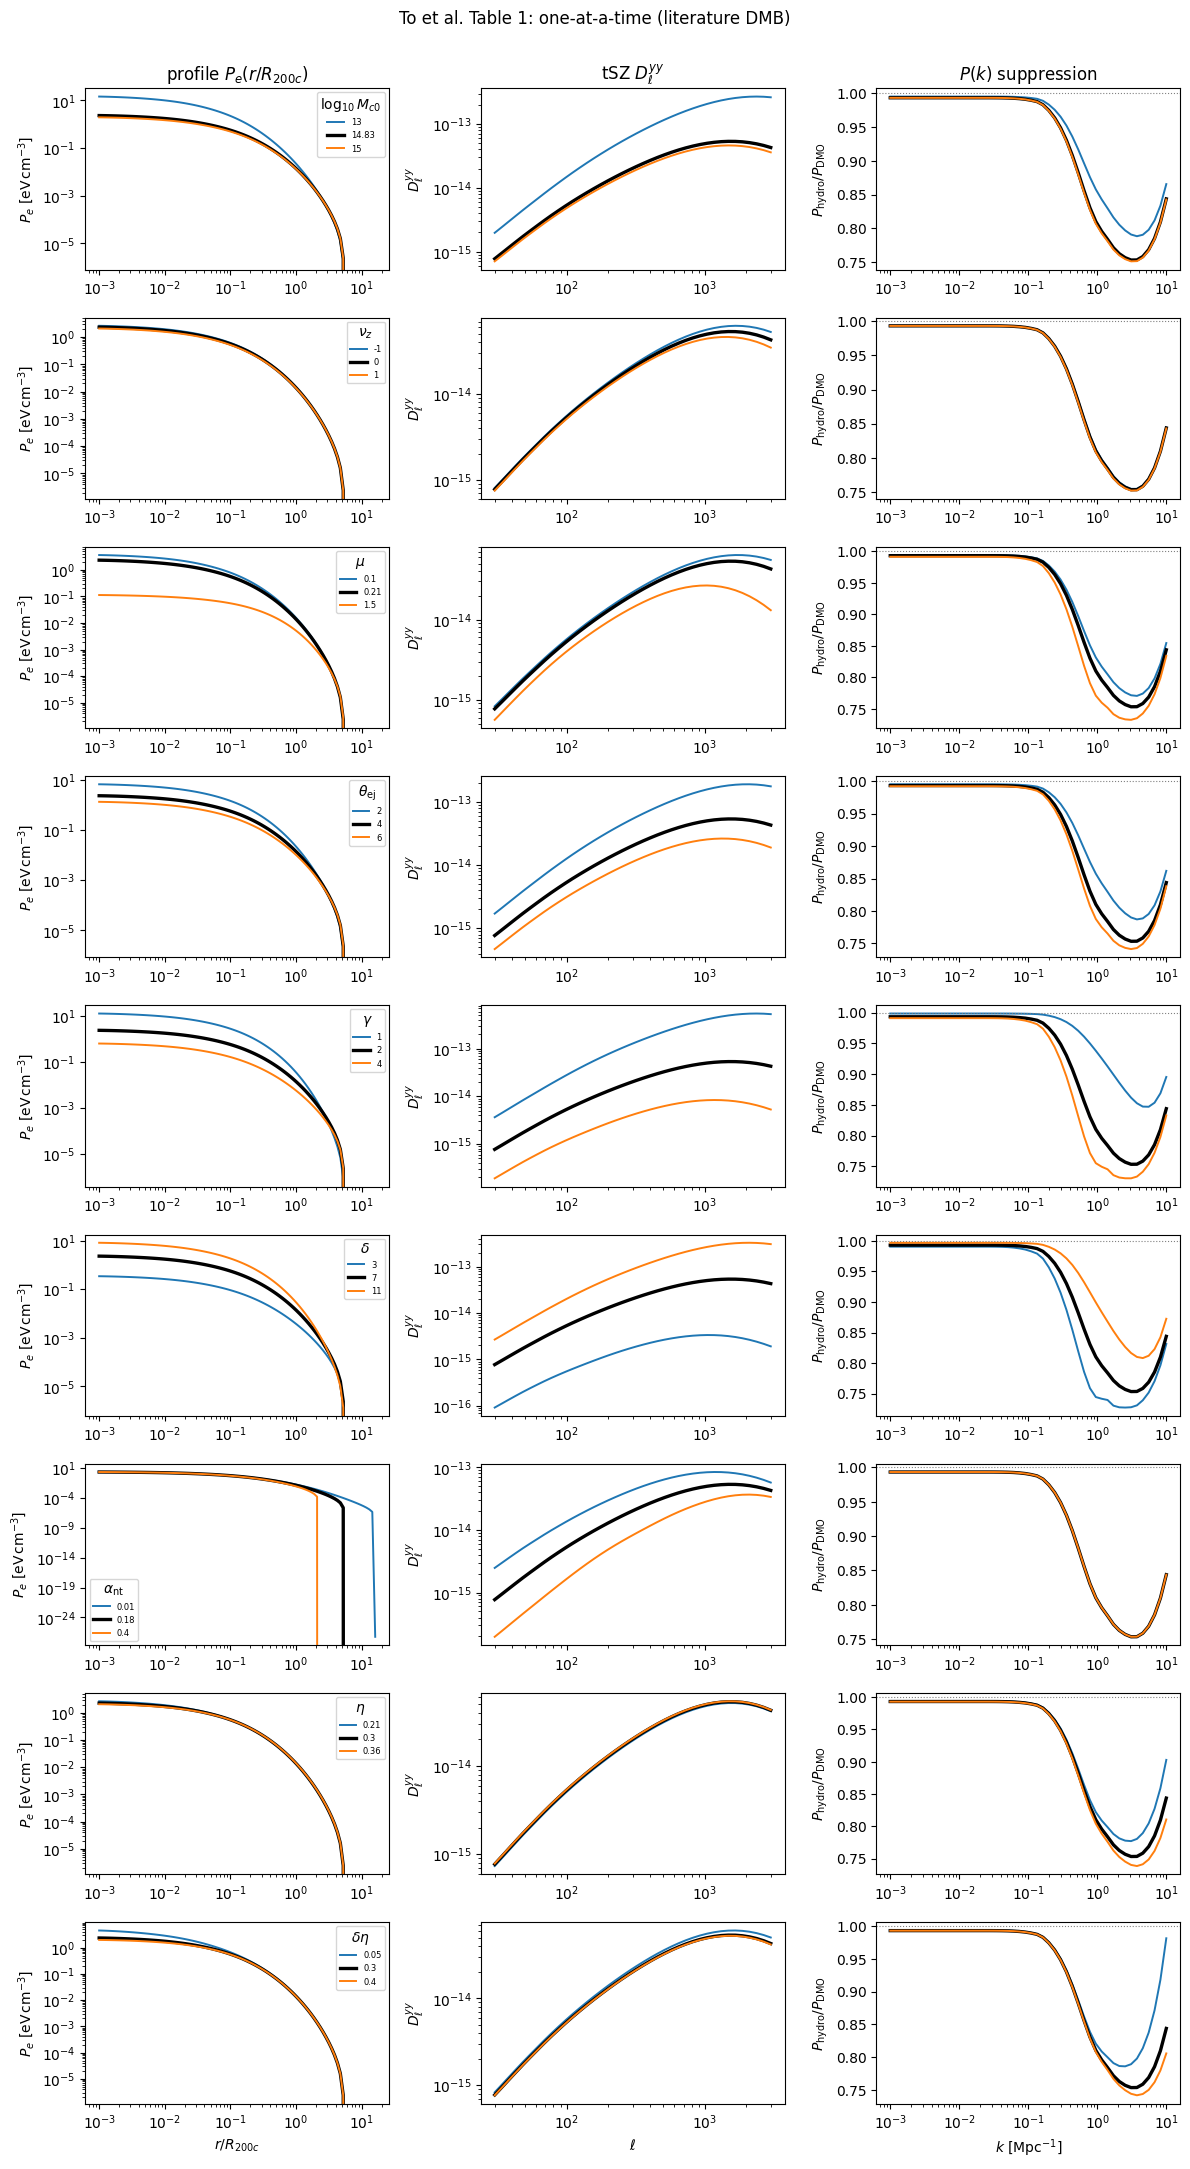

In [6]:
nrow = len(SCANS)
fig, axes = plt.subplots(nrow, 3, figsize=(12, 2.4 * nrow))
for i, (title, key, values) in enumerate(SCANS):
    ax_p, ax_t, ax_s = axes[i]
    for v in values:
        is_fid = np.isclose(v, FID[key])
        kw = dict(color=("k" if is_fid else None), lw=(2.4 if is_fid else 1.4), label=f"{v:g}")
        xr, pe = scan_pe[key][v]
        ax_p.loglog(xr, pe, **kw)
        ax_t.loglog(ell, to_dell(scan_cl[key][v]), **kw)
        ax_s.semilogx(k_arr, scan_Sk[key][v], **kw)
    ax_s.axhline(1.0, color="0.5", ls=":", lw=0.8)
    ax_p.set_ylabel(r"$P_e$ [eV$\,$cm$^{-3}$]")
    ax_t.set_ylabel(r"$D_\ell^{yy}$")
    ax_s.set_ylabel(r"$P_{\rm hydro}/P_{\rm DMO}$")
    ax_p.legend(fontsize=6, title=title, loc="best")
    if i == 0:
        ax_p.set_title(r"profile $P_e(r/R_{200c})$")
        ax_t.set_title(r"tSZ $D_\ell^{yy}$")
        ax_s.set_title(r"$P(k)$ suppression")
axes[-1, 0].set_xlabel(r"$r/R_{200c}$")
axes[-1, 1].set_xlabel(r"$\ell$")
axes[-1, 2].set_xlabel(r"$k$ [Mpc$^{-1}$]")
fig.suptitle(r"To et al. Table 1: one-at-a-time (literature DMB)", y=1.002)
plt.tight_layout()
plt.show()


## Takeaways

- **Convention:** `convention="literature"` throughout (To et al. 2024 / Dalal et al. 2026; not GODMAX).
- **Rows:** To et al. (2024) Table 1 gas + stellar parameters (not \(\sigma_{\ln Y}\)).
- **Columns:** \(P_e\) profile, tSZ \(D_\ell^{yy}\), \(P_{\rm hydro}/P_{\rm DMO}\).
- **\(P(k)\) suppression:** `hm_pk` with `hm_consistency=True` (1h and 2h lowest-mass counterterms on hydro and DMO). Matter windows share kernel \(M_{\rm tot}\).
- **tSZ:** `hm` with `hm_consistency=False`; pressure is not mass-rescaled.
- \(\alpha_{\rm nt}\) moves \(P_e\) and tSZ more than \(S(k)\); \(\theta_{\rm ej}\) moves all three.

Related: `tsz_power_spectrum.ipynb`, `dmb_observables.ipynb`.
